Experimental parameters: <br>
KOH concs: 0.25, 0.5, 1 (M) <br>
CO Pressure: 0.1, 1, 10, 100 (%) <br>
12 different condiitons for each basic CO oxidation: 3 different setups <br>
Potential ranges: 0.5 - 1 (vs RHE) (But data is already in SHE) <br>
Catalyst: Ag10Pd90 <br>
<br>
Units: <br>
Potential: V vs SHE <br>
Current: ln(uA/cm2) <br>
<br>
Data has replicates (3 replicates for each condition) <br>
Data was interpolated (Pchipinterpolation) to put all data sets on the same grid. <br>
Calculate mean and SD for each rate. <br> 
Calculate mean and SD for KOs. Calculate individual KOs first and then average. <br>
Save final data and import in different workspace. <br>

Data is truncated to alpha_min in each case to remove current that is affected by oxidized surface (formation of extra oxidized species like O*). <br>

# Initialization

In [2]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
import sys

utils_path = r"C:\Users\awast\OneDrive\Desktop\MKM"
sys.path.append(utils_path)
import _plotting_defaults

In [3]:
# Experimental conditions (Ag10Pd90 KOH) and constants

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
trials = [1, 2, 3]
conditions = list(itertools.product(C_KOH_list, P_CO_list))
conditions_trials = list(itertools.product(C_KOH_list, P_CO_list, trials))

R, T, F = 8.3145, 293.15, 96485
n = 2 # number of electrons transferred in the reaction
slope_f = np.log(10) * R * T / F # Tafel slope factor in V/decade
 
number_of_points = 41 # For a dE of 0.01 V = 10 mV

# Set to 0 to cut exactly at min alpha
# Set to an integer (e.g., 10) to include 10 points after the peak
# Set to None to include ALL data (no truncation)
buffer_after_min = None

gamma = 210e-6 / F # moles of Pd per cm2, 1cm2 Pd = 210 uC 

In [4]:
# Load current density data + classification

excel_file = 'Ag10Pd90_current_densities.xlsx'
experiments = {}
sheet_mapping = {0.001: '0.1% CO', 0.01: '1% CO', 0.1: '10% CO', 1.0: '100% CO'}
koh_col_mapping = {1: [1, 2, 3], 0.5: [4, 5, 6], 0.25: [7, 8, 9]}
for P_CO in P_CO_list: 
    sheet_name = sheet_mapping[P_CO]
    df = pd.read_excel(excel_file, sheet_name=sheet_name, header=0) 
    for C_KOH in C_KOH_list:
        trial_cols = koh_col_mapping[C_KOH]
        for trial_idx, trial in enumerate(trials): 
            col_idx = trial_cols[trial_idx]
            subset = df.iloc[:, [0, col_idx]].copy()
            subset.columns = ['E', 'j']
            subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
            subset['j'] = pd.to_numeric(subset['j'], errors='coerce')
            subset['j'] = np.exp(subset['j']) / 1000.0
            subset = subset.dropna()
            experiments[(C_KOH, P_CO, trial)] = subset

# Interpolating and Averaging

In [5]:
# Define common grid, interpolate and calculate averages

all_min_SHE = min(df['E'].min() for (C, _, _), df in experiments.items())
all_max_SHE = max(df['E'].max() for (C, _, _), df in experiments.items())
dE = (all_max_SHE - all_min_SHE) / (number_of_points - 1)
master_E_grid = np.arange(np.floor(all_min_SHE / dE) * dE, np.ceil(all_max_SHE / dE) * dE + dE, dE)
experiments_interp, experiments_mean, untruncated_data = {}, {}, {}

for P_CO in P_CO_list:
    for C_KOH in C_KOH_list:
        local_min_SHE = max(experiments[(C_KOH, P_CO, t)]['E'].min() for t in trials)
        local_max_SHE = min(experiments[(C_KOH, P_CO, t)]['E'].max() for t in trials)
        mask = (master_E_grid >= local_min_SHE - 1e-9) & (master_E_grid <= local_max_SHE + 1e-9)
        E_grid_SHE = master_E_grid[mask]
        buffer_pts = buffer_after_min if buffer_after_min is not None else 0

        rate_fulls, log_rate_fulls, cutoffs = [], [], []
        for trial in trials:
            cond = (C_KOH, P_CO, trial)
            df = experiments[cond]
            df_trunc = df[(df['E'] >= local_min_SHE) & (df['E'] <= local_max_SHE)]
            rate_interp = PchipInterpolator(df_trunc['E'], df_trunc['j'] / (1000 * n * F * gamma))(E_grid_SHE)
            log_rate_interp = np.log(rate_interp)
            alpha = (R * T / F) * np.gradient(log_rate_interp, E_grid_SHE)

            cutoffs.append(np.argmin(alpha[5:]) + 5 + buffer_pts if buffer_after_min is not None else len(E_grid_SHE))
            rate_fulls.append(rate_interp)
            log_rate_fulls.append(log_rate_interp)
            untruncated_data[cond] = {
                'E': E_grid_SHE,
                'rate': rate_interp,
                'log_rate': log_rate_interp,
            }

        final_cut = min(max(cutoffs), len(E_grid_SHE))
        E_final = E_grid_SHE[:final_cut]
        rate_mat = [rate_full[:final_cut] for rate_full in rate_fulls]
        log_rate_mat = [log_rate_full[:final_cut] for log_rate_full in log_rate_fulls]

        for trial, rate_full, log_rate_full in zip(trials, rate_fulls, log_rate_fulls):
            cond = (C_KOH, P_CO, trial)
            r_final = rate_full[:final_cut]
            lr_final = log_rate_full[:final_cut]
            experiments_interp[cond] = {
                'E': E_final,
                'rate': r_final,
                'log_rate': lr_final,
                'j': r_final * (1000 * n * F * gamma),
            }

        experiments_mean[(C_KOH, P_CO)] = {
            'truncated_E': E_final,
            'truncated_rate': np.mean(rate_mat, axis=0),
            'truncated_rate_SD': np.std(rate_mat, axis=0, ddof=1),
            'truncated_log_rate': np.mean(log_rate_mat, axis=0),
            'truncated_log_rate_SD': np.std(log_rate_mat, axis=0, ddof=1),
            'truncated_rate_matrix': rate_mat,
            'E': E_grid_SHE,
            'rate': np.mean(rate_fulls, axis=0),
            'rate_SD': np.std(rate_fulls, axis=0, ddof=1),
            'log_rate': np.mean(log_rate_fulls, axis=0),
            'log_rate_SD': np.std(log_rate_fulls, axis=0, ddof=1),
        }

# Rates

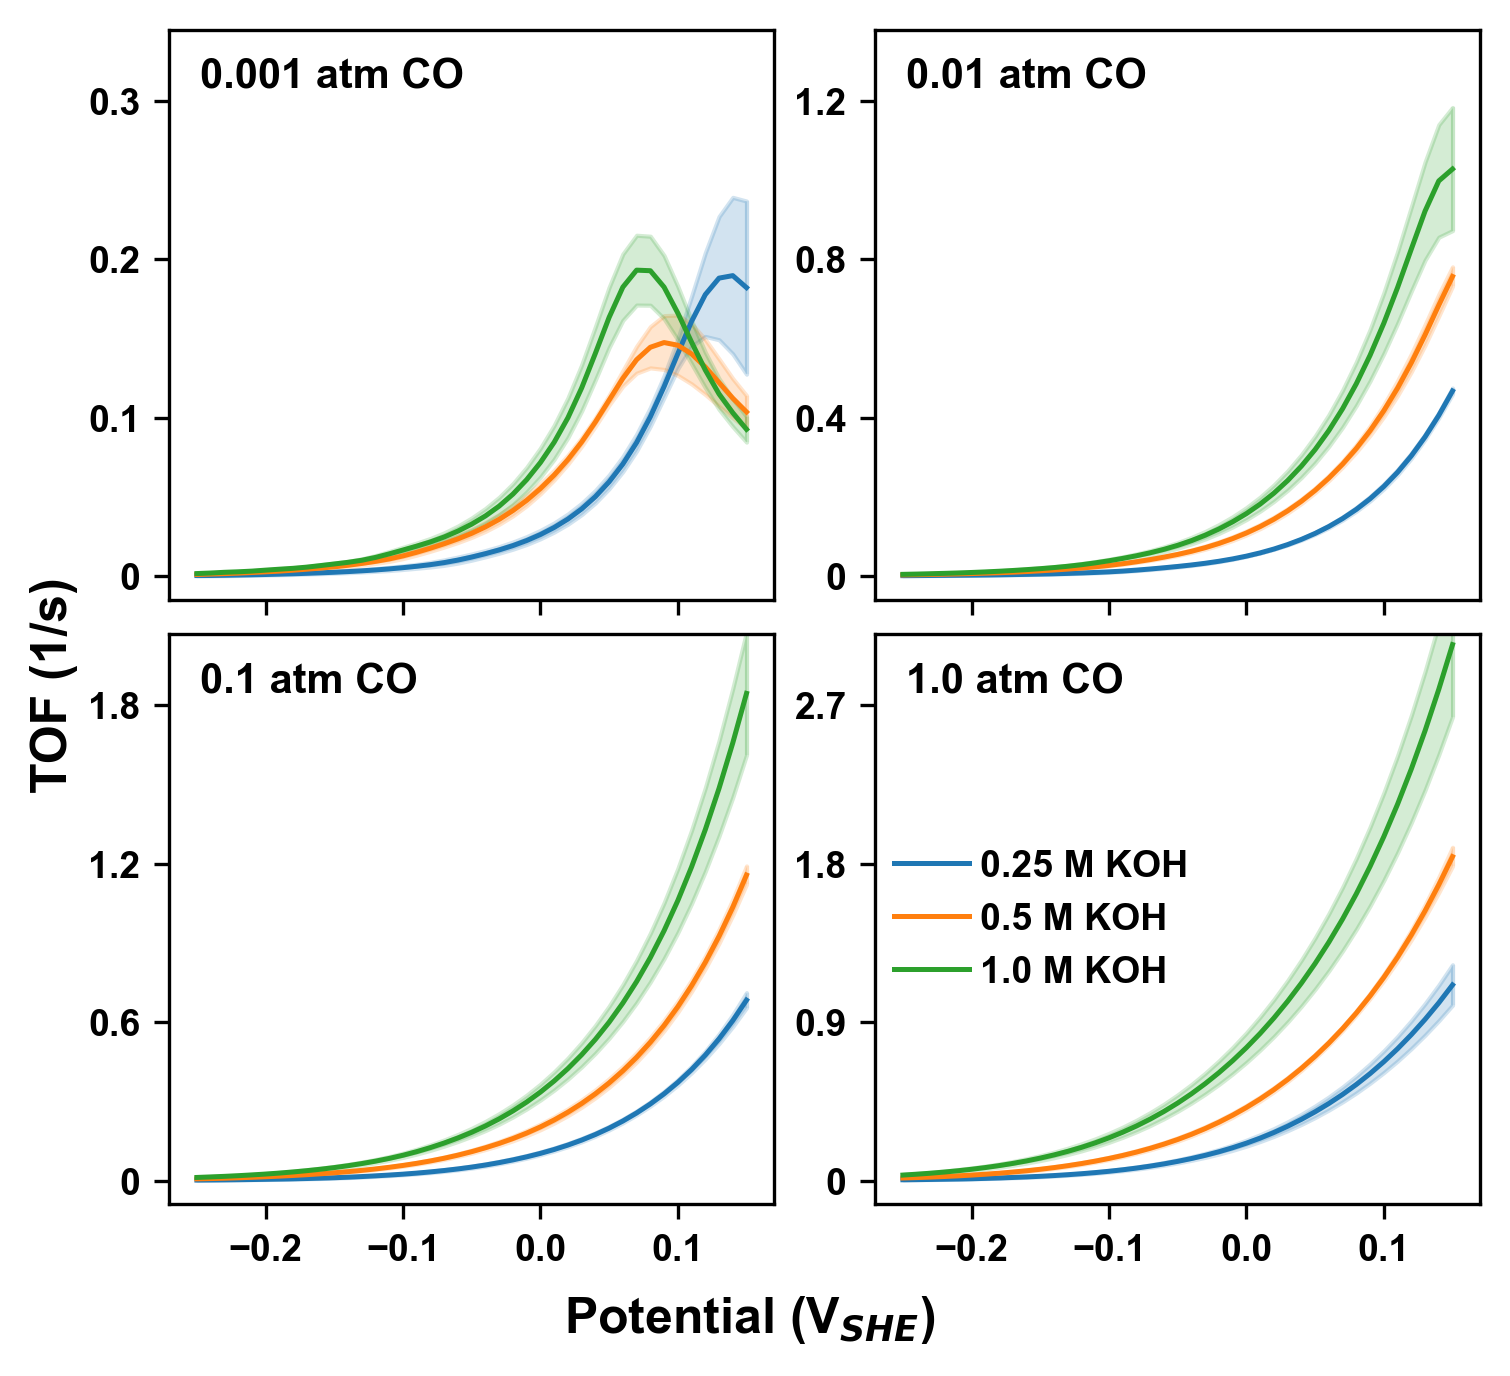

In [6]:
# Plot rates (TOF)

fig, axes = plt.subplots(2, 2, figsize=(5.0, 4.5), dpi=300, sharex=True)
axes = axes.flatten()
titles = ["0.001 atm CO", "0.01 atm CO", "0.1 atm CO", "1.0 atm CO"]
y_limits = {"0.001 atm CO": 0.3, "0.01 atm CO": 1.2, "0.1 atm CO": 1.8, "1.0 atm CO": 2.7}

for i, (ax, title_str) in enumerate(zip(axes, titles)):
    P_CO, y_max = P_CO_list[i], y_limits[titles[i]]

    for C_KOH in C_KOH_list:
        d = experiments_mean[(C_KOH, P_CO)]

        # Solid = truncated region used for fitting
        line, = ax.plot(d['truncated_E'], d['truncated_rate'], lw=1.2, label=f'{C_KOH} M KOH')
        color = line.get_color()
        ax.fill_between(
            d['truncated_E'],
            d['truncated_rate'] - d['truncated_rate_SD'],
            d['truncated_rate'] + d['truncated_rate_SD'],
            color=color,
            alpha=0.2,
        )

        # Dashed = truncated-off tail (untruncated data beyond truncated_E)
        mask = d['E'] >= np.max(d['truncated_E'])
        E_t, r_t = d['E'][mask], d['rate'][mask]
        err_t = d['rate_SD'][mask]

        ax.plot(E_t, r_t, color=color, lw=1.2, ls='--', alpha=0.8)
        ax.fill_between(E_t, r_t - err_t, r_t + err_t, color=color, alpha=0.08)

    ticks = [0, y_max / 3, 2 * y_max / 3, y_max]
    ax.set_yticks(ticks)
    ax.set_yticklabels([f'{v:.3g}' for v in ticks])
    ax.set_ylim(-0.05 * y_max, y_max + (0.15 * y_max))
    ax.tick_params(labelsize=9)
    ax.text(0.05, 0.95, title_str, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top')
    if i == 3:
        ax.legend(fontsize=9, frameon=False, loc='center left')

fig.supxlabel(r'Potential (V$_{SHE}$)', fontsize=12, fontweight='bold')
fig.supylabel('TOF (1/s)', fontsize=12, fontweight='bold')
plt.tight_layout(pad=0.4)
# plt.savefig('fig_Ag10Pd90_TOF.svg', dpi=300)
plt.show()

In [7]:
# Calculate alpha from UNTRUNCATED data for plotting reference

for condition_trial in conditions_trials:
    E = untruncated_data[condition_trial]['E']
    lnj = untruncated_data[condition_trial]['log_rate']

    alpha = (R*T/F)*np.gradient(lnj, E)    
    untruncated_data[condition_trial]['alpha'] = alpha

for condition in conditions:
    C_KOH, P_CO = condition
    alpha_trials = []
    for trial in trials:
        condition_trial = (C_KOH, P_CO, trial)
        alpha_trials.append(untruncated_data[condition_trial]['alpha'])
        
    alpha_array = np.array(alpha_trials)
    experiments_mean[condition]['alpha'] = np.mean(alpha_array, axis=0)
    experiments_mean[condition]['alpha_SD'] = np.std(alpha_array, axis=0, ddof=1)

# Transfer Coefficients

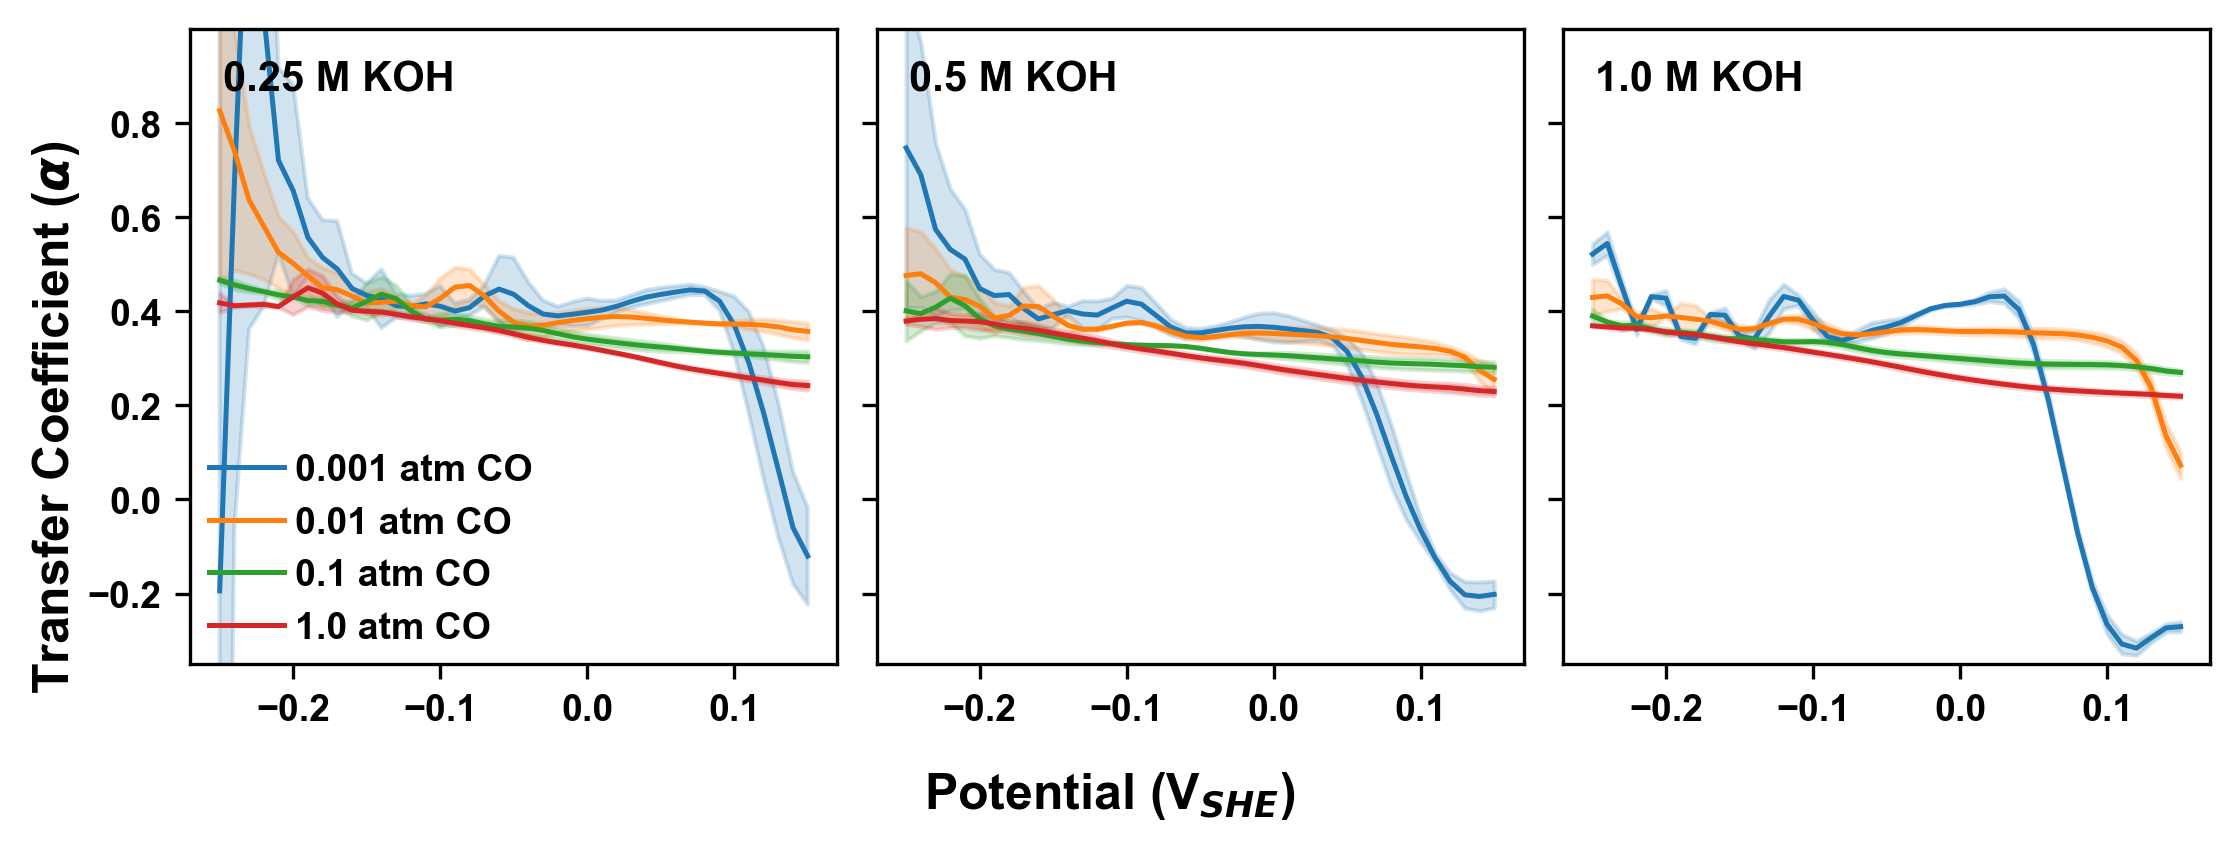

In [8]:
# Plotting alphas 

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.75), dpi=300, sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, C_KOH) in enumerate(zip(axes, C_KOH_list)):
    for P_CO in P_CO_list:
        cond = (C_KOH, P_CO)
        d = experiments_mean[cond]
        line, = ax.plot(d['E'], d['alpha'], lw=1.2, label=f'{P_CO} atm CO')
        color = line.get_color()
        ax.fill_between(d['E'], d['alpha'] - d['alpha_SD'], 
                        d['alpha'] + d['alpha_SD'], color=color, alpha=0.2)

    span = 1
    ax.set_yticks([-0.2, 0.0, 0.2, 0.4, 0.6 , 0.8])
    ax.set_ylim(-0.3 - (0.05 * span), 0.8 + (0.2 * span)) 
    ax.tick_params(labelsize=9)
    
    ax.text(0.05, 0.95, f'{C_KOH} M KOH', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top')
    if i == 0: 
        ax.legend(fontsize=9, frameon=False, loc='lower left')

fig.supxlabel(r'Potential (V$_{SHE}$)', fontsize=12, fontweight='bold')
fig.supylabel(r'Transfer Coefficient ($\alpha$)', fontsize=12, fontweight='bold')
plt.tight_layout(pad=0.5)
# plt.savefig('fig_Ag10Pd90_KOH_alpha.svg', dpi=300)
plt.show()

In [9]:
# Calculate delta_OH from UNTRUNCATED data for plotting reference

for P_CO in P_CO_list:
    for trial in trials:
        common_E = None
        for C_KOH in C_KOH_list:
            E_SHE = untruncated_data[(C_KOH, P_CO, trial)]['E']
            if common_E is None: common_E = set(np.round(E_SHE, 6))
            else: common_E = common_E.intersection(np.round(E_SHE, 6))
        common_E = np.sort(list(common_E))
        
        log_rate_matrix = []
        for C_KOH in C_KOH_list:
            E_SHE = np.round(untruncated_data[(C_KOH, P_CO, trial)]['E'], 6)
            lr = untruncated_data[(C_KOH, P_CO, trial)]['log_rate']
            mask = np.isin(E_SHE, common_E)
            log_rate_matrix.append(lr[mask])
        log_rate_matrix = np.array(log_rate_matrix) 
        
        delta_OH = np.polyfit(np.log(C_KOH_list), log_rate_matrix, deg=1)[0]
        
        for C_KOH in C_KOH_list: 
            untruncated_data[(C_KOH, P_CO, trial)]['delta_OH'] = delta_OH 
            untruncated_data[(C_KOH, P_CO, trial)]['common_E_OH'] = common_E

for condition in conditions: 
    C_KOH, P_CO = condition
    delta_OH_trials = [untruncated_data[(C_KOH, P_CO, trial)]['delta_OH'] for trial in trials]
    delta_OH_array = np.array(delta_OH_trials)
    experiments_mean[condition]['E_OH'] = untruncated_data[(C_KOH, P_CO, 1)]['common_E_OH'] 
    experiments_mean[condition]['delta_OH'] = np.mean(delta_OH_array, axis=0) 
    experiments_mean[condition]['delta_OH_SD'] = np.std(delta_OH_array, axis=0, ddof=1)

# OH Reaction Order

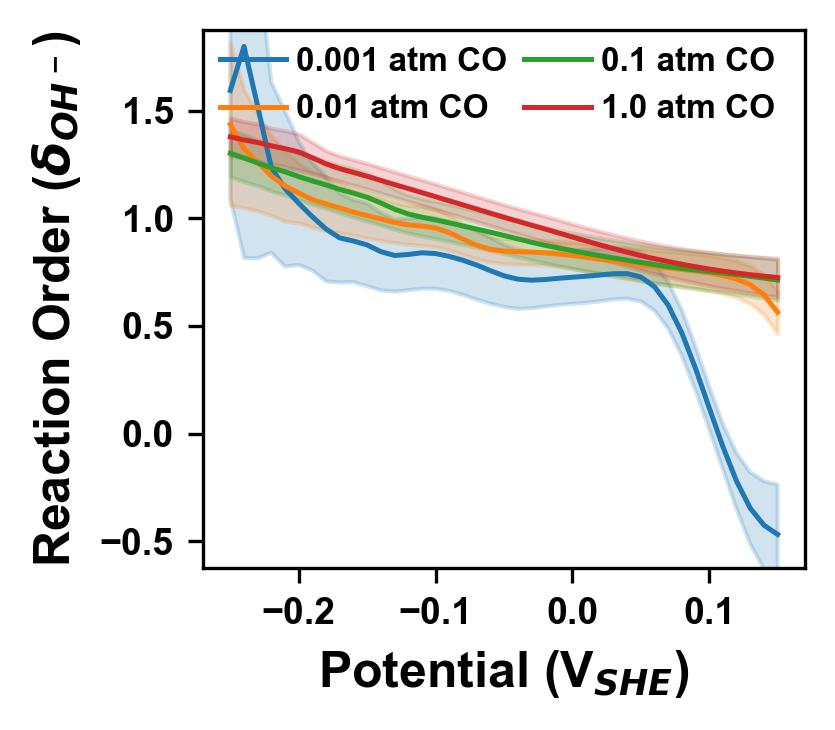

In [10]:
# Plotting delta_OH

fig = plt.figure(figsize=(2.75, 2.4), dpi=300)
ax = plt.subplot(1, 1, 1)

for P_CO in P_CO_list:
    d = experiments_mean[(C_KOH_list[0], P_CO)]
    line, = ax.plot(d['E_OH'], d['delta_OH'], lw=1.2, label=f'{P_CO} atm CO')
    color = line.get_color()
    ax.fill_between(d['E_OH'], d['delta_OH'] - d['delta_OH_SD'], 
                    d['delta_OH'] + d['delta_OH_SD'], color=color, alpha=0.2)

span = 2.5 
ax.set_yticks([-0.5, 0.0, 0.5, 1.0, 1.5])
ax.set_ylim(-0.5 - (0.05 * span), 1.5 + (0.15 * span))
ax.tick_params(labelsize=9)
ax.set_xlabel(r'Potential (V$_{SHE}$)', fontsize=12, fontweight='bold')
ax.set_ylabel(r'Reaction Order ($\delta_{OH^-}$)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, frameon=False, loc='upper left', ncol=2, columnspacing=0.5)
plt.tight_layout(pad=0.5)
# plt.savefig('fig_Ag10Pd90_KOH_delta_OH.svg', dpi=300)
plt.show()

In [11]:
# Calculate delta_CO from UNTRUNCATED data for plotting reference

conditions_delta_CO = list(itertools.product(C_KOH_list, P_CO_list[0:-1]))
for C_KOH in C_KOH_list:
    for trial in trials: 
        for i in range(len(P_CO_list) - 1):
            P_CO_1 = P_CO_list[i]
            P_CO_2 = P_CO_list[i+1]
            E_1 = np.round(untruncated_data[(C_KOH, P_CO_1, trial)]['E'], 6)
            E_2 = np.round(untruncated_data[(C_KOH, P_CO_2, trial)]['E'], 6)
            common_E = np.intersect1d(E_1, E_2)
            mask_1 = np.isin(E_1, common_E)
            mask_2 = np.isin(E_2, common_E)
            ln_j_1 = untruncated_data[(C_KOH, P_CO_1, trial)]['log_rate'][mask_1]
            ln_j_2 = untruncated_data[(C_KOH, P_CO_2, trial)]['log_rate'][mask_2]
            
            delta_CO = (ln_j_2 - ln_j_1) / np.log(P_CO_2 / P_CO_1)
            
            untruncated_data[(C_KOH, P_CO_1, trial)]['delta_CO'] = delta_CO
            untruncated_data[(C_KOH, P_CO_1, trial)]['common_E_CO'] = common_E

for C_KOH in C_KOH_list:
    for i in range(len(P_CO_list) - 1):
        P_CO_1 = P_CO_list[i]
        condition = (C_KOH, P_CO_1)
        delta_CO_trials = [untruncated_data[(C_KOH, P_CO_1, trial)]['delta_CO'] for trial in trials]
        delta_CO_array = np.array(delta_CO_trials)
        experiments_mean[condition]['E_CO'] = untruncated_data[(C_KOH, P_CO_1, 1)]['common_E_CO']
        experiments_mean[condition]['delta_CO'] = np.mean(delta_CO_array, axis=0) 
        experiments_mean[condition]['delta_CO_SD'] = np.std(delta_CO_array, axis=0, ddof=1)

# CO Reaction Order

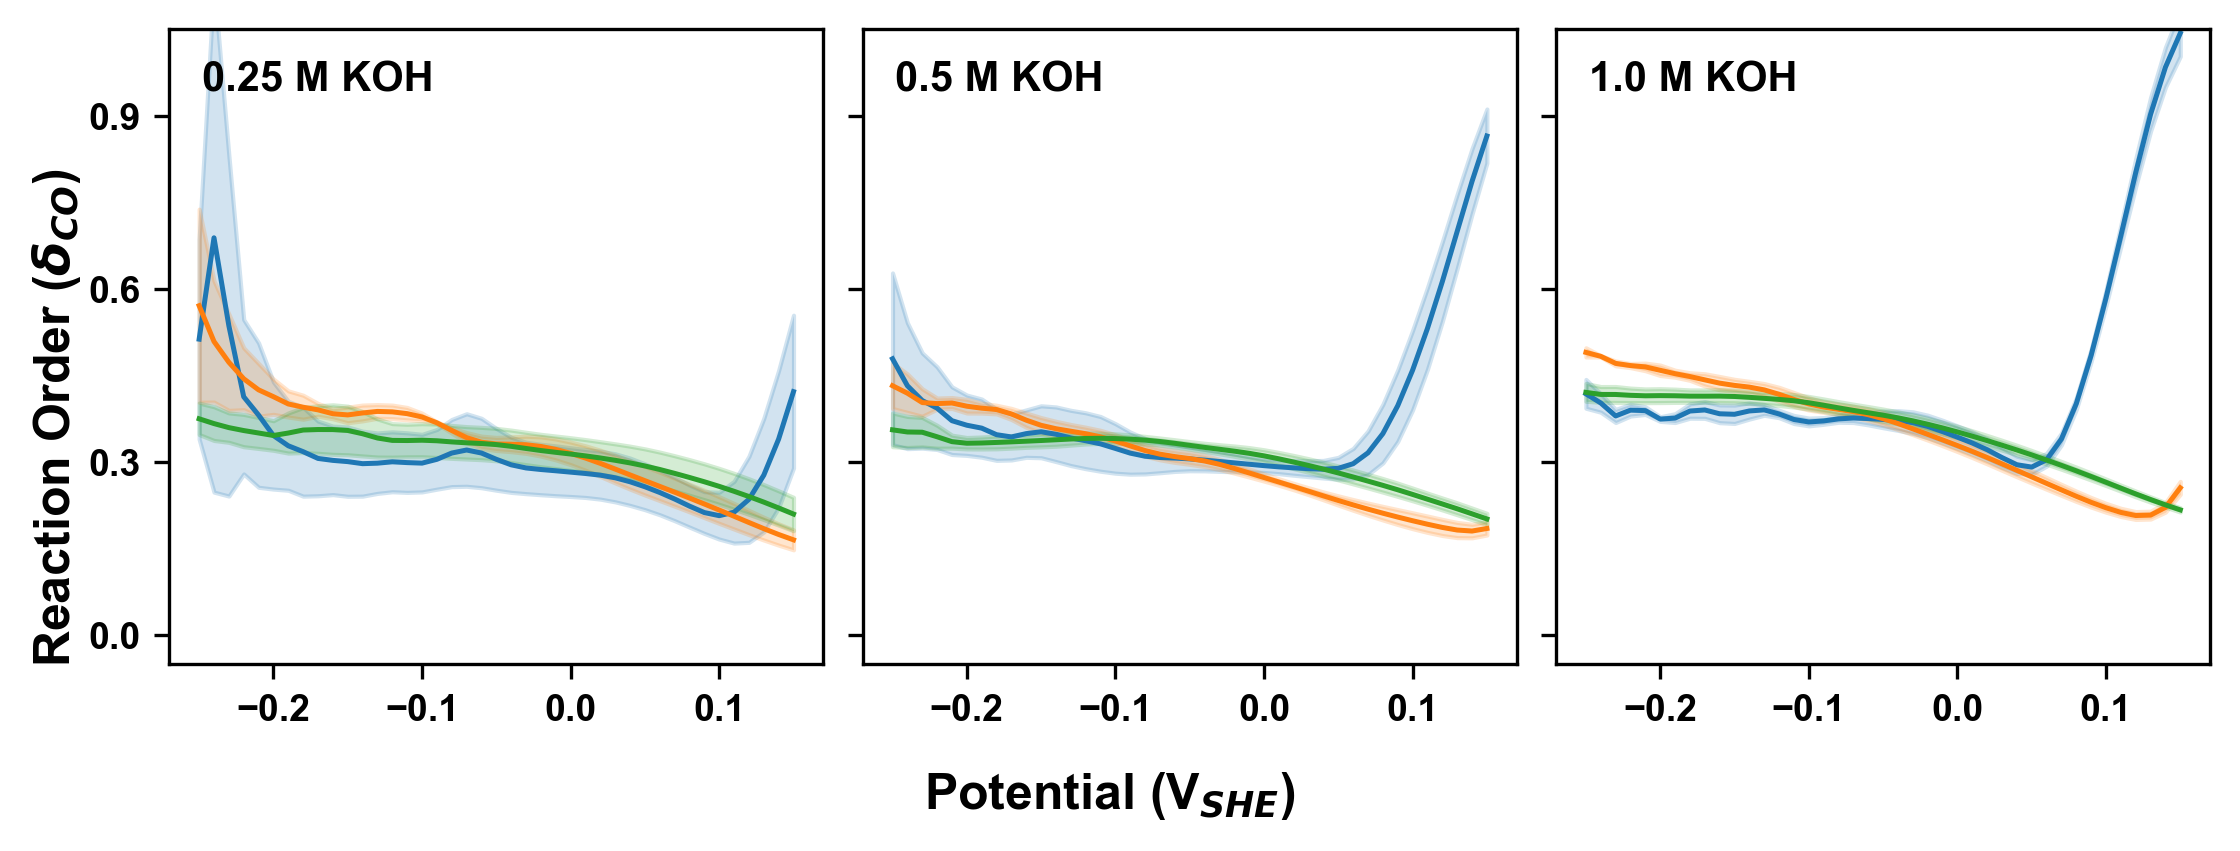

In [12]:
# Plotting delta_CO

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.75), dpi=300, sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, target_KOH) in enumerate(zip(axes, C_KOH_list)):
    for (C_KOH, P_CO) in [c for c in conditions_delta_CO if c[0] == target_KOH]:
        d = experiments_mean[(C_KOH, P_CO)]
        idx = np.where(P_CO_list == P_CO)[0][0]
        label_str = f'{P_CO}-{P_CO_list[idx+1]} atm'
        line, = ax.plot(d['E_CO'], d['delta_CO'], lw=1.2, label=label_str)
        color = line.get_color()
        ax.fill_between(d['E_CO'], d['delta_CO'] - d['delta_CO_SD'], 
                        d['delta_CO'] + d['delta_CO_SD'], color=color, alpha=0.2)

    span = 1.0 
    ax.set_yticks([0.0, 0.3, 0.6, 0.9])
    ax.set_ylim(0 - (0.05 * span), 0.9 + (0.15 * span))
    ax.tick_params(labelsize=9)
    ax.text(0.05, 0.95, f'{target_KOH} M KOH', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top')
    if i == 3: ax.legend(fontsize=8, frameon=False, loc='lower right')

fig.supxlabel(r'Potential (V$_{SHE}$)', fontsize=12, fontweight='bold')
fig.supylabel(r'Reaction Order ($\delta_{CO}$)', fontsize=12, fontweight='bold')
plt.tight_layout(pad=0.5)
# plt.savefig('fig_Ag10Pd90_KOH_delta_CO.svg', dpi=300)
plt.show()

In [13]:
import pickle
with open('import_Ag10Pd90_replicates.pkl', 'wb') as f:
    pickle.dump(experiments_mean, f)

In [14]:
experiments_mean

{(np.float64(0.25),
  np.float64(0.001)): {'truncated_E': array([-2.50000000e-01, -2.40000000e-01, -2.30000000e-01, -2.20000000e-01,
         -2.10000000e-01, -2.00000000e-01, -1.90000000e-01, -1.80000000e-01,
         -1.70000000e-01, -1.60000000e-01, -1.50000000e-01, -1.40000000e-01,
         -1.30000000e-01, -1.20000000e-01, -1.10000000e-01, -1.00000000e-01,
         -9.00000000e-02, -8.00000000e-02, -7.00000000e-02, -6.00000000e-02,
         -5.00000000e-02, -4.00000000e-02, -3.00000000e-02, -2.00000000e-02,
         -1.00000000e-02,  2.22044605e-16,  1.00000000e-02,  2.00000000e-02,
          3.00000000e-02,  4.00000000e-02,  5.00000000e-02,  6.00000000e-02,
          7.00000000e-02,  8.00000000e-02,  9.00000000e-02,  1.00000000e-01,
          1.10000000e-01,  1.20000000e-01,  1.30000000e-01,  1.40000000e-01,
          1.50000000e-01]), 'truncated_rate': array([0.00019109, 0.00024387, 0.00036249, 0.00051374, 0.0006751 ,
         0.00086668, 0.00108378, 0.00132548, 0.00160799, 0.00